# 1.0 Loading Historical Stock Prices

In [4]:
import numpy as np, pandas as pd
import matplotlib.pyplot as plt

In [15]:
price_df = pd.DataFrame(df.to_numpy(),index=range(1, len(df) + 1), columns=df.columns)
price_df

,ALGO,AENO,LSST,SRNA,ELLT,AMRP,OTCS,HETT,HUXZ,DUCT,...,BLBT,BENI,ITPA,HTRK,NGTE,ILVX,FCSG,FARS,MHRM,EAFC
1,100.00,116.51,113.55,134.23,64.12,25.05,14.68,59.24,83.62,19.71,...,52.23,32.37,18.82,10.86,52.65,32.58,27.46,66.43,22.41,45.08
2,98.49,112.94,114.53,133.21,62.74,23.96,14.55,58.28,79.94,19.22,...,52.73,32.25,18.41,10.77,49.71,31.66,26.47,64.66,22.10,44.28
3,97.83,112.70,112.17,132.80,61.61,23.30,14.69,57.97,81.20,19.22,...,53.23,32.23,18.22,10.69,50.53,30.84,25.28,64.19,20.87,45.30
4,98.02,112.26,116.09,133.16,63.55,23.47,14.43,57.02,81.82,19.39,...,52.67,32.20,18.22,10.28,51.64,30.95,24.60,62.80,20.95,46.32
5,99.13,113.59,119.58,137.20,63.64,23.61,14.61,58.78,83.01,19.91,...,53.59,32.33,18.25,10.50,53.57,31.49,25.66,63.94,20.72,45.56
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
496,84.85,60.13,88.97,74.82,75.23,16.72,32.67,53.61,44.78,11.00,...,33.90,25.50,20.61,11.14,33.73,40.78,32.53,32.28,8.41,17.11
497,85.60,61.91,86.92,75.48,75.79,17.59,32.11,54.62,45.34,11.24,...,34.12,25.51,20.88,11.19,34.47,40.97,34.51,32.51,8.52,17.65
498,86.31,62.52,86.26,77.33,79.75,18.25,32.28,55.92,46.35,11.44,...,34.50,25.75,21.72,11.16,34.94,41.89,35.03,33.17,8.67,17.58
499,87.14,62.30,87.59,77.29,81.38,19.29,32.40,56.58,46.34,11.76,...,34.80,25.99,22.16,11.26,34.99,41.43,36.29,33.52,9.00,17.93


## Describing Data

In [18]:
price_df.info()
price_df.describe()
if price_df.isnull().values.any():
    fill_values = price_df.fillna(method='ffill')

<class 'pandas.DataFrame'>
RangeIndex: 500 entries, 1 to 500
Data columns (total 51 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   ALGO    500 non-null    float64
 1   AENO    500 non-null    float64
 2   LSST    500 non-null    float64
 3   SRNA    500 non-null    float64
 4   ELLT    500 non-null    float64
 5   AMRP    500 non-null    float64
 6   OTCS    500 non-null    float64
 7   HETT    500 non-null    float64
 8   HUXZ    500 non-null    float64
 9   DUCT    500 non-null    float64
 10  SMAH    500 non-null    float64
 11  NPCK    500 non-null    float64
 12  MSDP    500 non-null    float64
 13  EORC    500 non-null    float64
 14  CUBO    500 non-null    float64
 15  HRET    500 non-null    float64
 16  ANSO    500 non-null    float64
 17  DIHO    500 non-null    float64
 18  RTTH    500 non-null    float64
 19  SPLZ    500 non-null    float64
 20  NWIG    500 non-null    float64
 21  MMBT    500 non-null    float64
 22  MDGI    500 n

# 2.0 Returns and Distributions

In [20]:
returns = price_df.pct_change().dropna()
returns

,ALGO,AENO,LSST,SRNA,ELLT,AMRP,OTCS,HETT,HUXZ,DUCT,...,BLBT,BENI,ITPA,HTRK,NGTE,ILVX,FCSG,FARS,MHRM,EAFC
2,-0.015100,-0.030641,0.008631,-0.007599,-0.021522,-0.043513,-0.008856,-0.016205,-0.044009,-0.024860,...,0.009573,-0.003707,-0.021785,-0.008287,-0.055840,-0.028238,-0.036052,-0.026645,-0.013833,-0.017746
3,-0.006701,-0.002125,-0.020606,-0.003078,-0.018011,-0.027546,0.009622,-0.005319,0.015762,0.000000,...,0.009482,-0.000620,-0.010320,-0.007428,0.016496,-0.025900,-0.044957,-0.007269,-0.055656,0.023035
4,0.001942,-0.003904,0.034947,0.002711,0.031488,0.007296,-0.017699,-0.016388,0.007635,0.008845,...,-0.010520,-0.000931,0.000000,-0.038354,0.021967,0.003567,-0.026899,-0.021654,0.003833,0.022517
5,0.011324,0.011847,0.030063,0.030339,0.001416,0.005965,0.012474,0.030866,0.014544,0.026818,...,0.017467,0.004037,0.001647,0.021401,0.037374,0.017447,0.043089,0.018153,-0.010979,-0.016408
6,-0.004842,-0.023241,-0.012795,-0.002624,-0.008485,-0.032613,-0.027379,-0.019394,0.000241,-0.019086,...,0.013995,-0.012372,-0.008219,0.005714,0.017360,-0.003493,-0.016758,-0.002502,-0.013031,0.018876
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
496,-0.002821,0.028919,-0.006144,0.021294,-0.010132,0.015796,0.022855,-0.000373,0.007651,0.030928,...,-0.011662,0.006314,-0.006747,-0.001792,-0.011140,0.001228,0.054457,0.009697,0.025610,-0.011554
497,0.008839,0.029603,-0.023041,0.008821,0.007444,0.052033,-0.017141,0.018840,0.012506,0.021818,...,0.006490,0.000392,0.013100,0.004488,0.021939,0.004659,0.060867,0.007125,0.013080,0.031560
498,0.008294,0.009853,-0.007593,0.024510,0.052250,0.037521,0.005294,0.023801,0.022276,0.017794,...,0.011137,0.009408,0.040230,-0.002681,0.013635,0.022455,0.015068,0.020301,0.017606,-0.003966
499,0.009616,-0.003519,0.015419,-0.000517,0.020439,0.056986,0.003717,0.011803,-0.000216,0.027972,...,0.008696,0.009320,0.020258,0.008961,0.001431,-0.010981,0.035969,0.010552,0.038062,0.019909


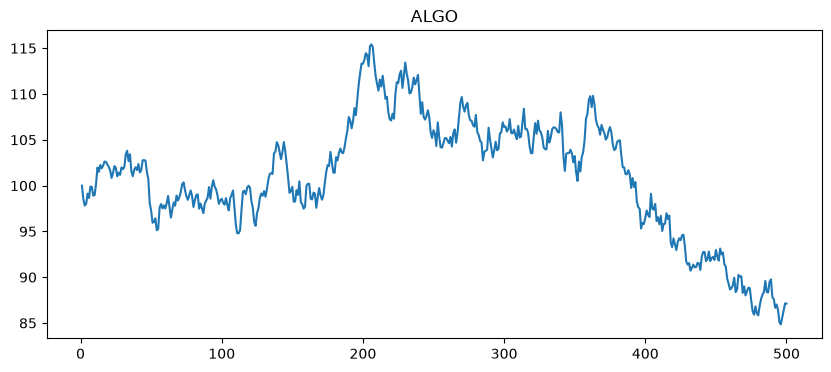

In [21]:
price_df.iloc[:, 0].plot(figsize=(10, 4), title=price_df.columns[0])
plt.show()

# 3.0 Relationship between assets

# 4.0 Possible Signal Explorations